# 01 - Análisis Exploratorio de Datos (EDA)
Dataset: Ames Housing (`data/train.csv`). Target: `SalePrice`.

Este notebook cubre la sección 2.1 del trabajo escrito: dimensiones y tipos de
variable, estadísticas descriptivas, nulos/outliers, visualizaciones y las
decisiones de preprocesamiento que de aquí se derivan (implementadas luego en
`src/preprocessing.py`).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

df = pd.read_csv("../data/train.csv")
df.shape

(1168, 81)

## 1. Dimensiones y tipos de variables

In [2]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"Categóricas ({len(categorical_cols)}): {categorical_cols}")

Filas: 1168, Columnas: 81
Numéricas (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categóricas (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fun

**Variable objetivo:** `SalePrice` (numérica continua, precio de venta en USD).

Entre las "numéricas" hay varias que en realidad son categóricas codificadas
como enteros (p.ej. `MSSubClass`, `OverallQual`, `OverallCond`, `MoSold`,
`YrSold`) — se documentan aquí y se tratan explícitamente en
`src/preprocessing.py` (algunas como ordinales, otras se dejan numéricas
porque ya tienen orden natural, p.ej. `OverallQual`).

## 2. Variable objetivo: SalePrice

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

Skewness: 1.743128561420854
Skewness log1p: 0.12489024367919244


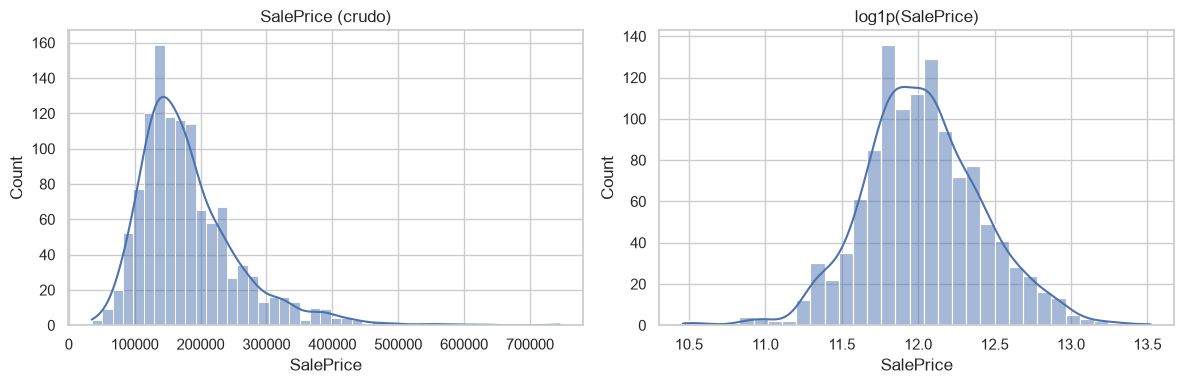

In [3]:
print(df["SalePrice"].describe())
print("\nSkewness:", df["SalePrice"].skew())
print("Skewness log1p:", np.log1p(df["SalePrice"]).skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice (crudo)")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")
plt.tight_layout()
plt.show()

`SalePrice` está sesgado a la derecha (cola de casas caras). `log1p(SalePrice)`
se ve mucho más simétrico -> se prueba como target alternativo en
`02_experiments.ipynb` (una de las iteraciones documentadas).

## 3. Estadísticas descriptivas

In [4]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1168.0,730.904966,425.369088,1.0,360.75,732.5,1101.75,1460.0
MSSubClass,1168.0,56.849315,42.531862,20.0,20.00,50.0,70.00,190.0
LotFrontage,951.0,70.343849,24.897021,21.0,59.00,70.0,80.00,313.0
LotArea,1168.0,10689.642123,10759.366198,1300.0,7587.25,9600.0,11700.00,215245.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
OverallCond,1168.0,5.584760,1.116062,1.0,5.00,5.0,6.00,9.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0
YearRemodAdd,1168.0,1984.897260,20.733955,1950.0,1966.00,1994.0,2004.00,2010.0
MasVnrArea,1162.0,103.771945,173.032238,0.0,0.00,0.0,166.00,1378.0
BsmtFinSF1,1168.0,446.023973,459.070977,0.0,0.00,384.5,721.00,5644.0


In [5]:
df[categorical_cols].describe().T

,count,unique,top,freq
MSZoning,1168,5,RL,924
Street,1168,2,Pave,1164
Alley,74,2,Grvl,44
LotShape,1168,4,Reg,729
LandContour,1168,4,Lvl,1059
Utilities,1168,2,AllPub,1167
LotConfig,1168,5,Inside,822
LandSlope,1168,3,Gtl,1108
Neighborhood,1168,25,NAmes,181
Condition1,1168,9,Norm,1004


## 4. Valores nulos

In [6]:
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
na_pct = (na_counts / len(df) * 100).round(1)
na_table = pd.DataFrame({"n_missing": na_counts, "pct_missing": na_pct})
na_table

,n_missing,pct_missing
PoolQC,1162,99.5
MiscFeature,1122,96.1
Alley,1094,93.7
Fence,935,80.1
MasVnrType,683,58.5
FireplaceQu,547,46.8
LotFrontage,217,18.6
GarageType,64,5.5
GarageYrBlt,64,5.5
GarageFinish,64,5.5


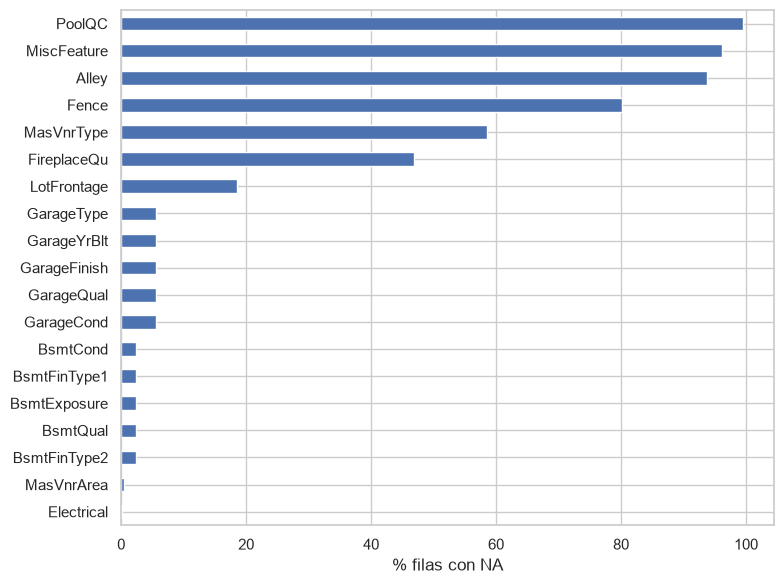

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
na_table["pct_missing"].plot(kind="barh", ax=ax)
ax.set_xlabel("% filas con NA")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Tratamiento de nulos (justificación):** según el data dictionary de Ames
Housing, la mayoría de estas columnas NO tienen missing real — el NA
representa "esta casa no tiene ese feature": `PoolQC`, `MiscFeature`,
`Alley`, `Fence`, `FireplaceQu`, `GarageType/Finish/Qual/Cond`,
`BsmtQual/Cond/Exposure/FinType1/FinType2`, `MasVnrType`. Se rellenan con la
categoría `"None"` (o `0` para las numéricas `GarageYrBlt` y `MasVnrArea`) en
vez de imputar con moda/media, porque hacerlo así perdería la señal de
"sin garage" / "sin sótano".

`LotFrontage` (217 NA, ~18%) y `Electrical` (1 NA) sí son missing real —
`LotFrontage` se imputa con la mediana y `Electrical` con la moda dentro del
pipeline de preprocesamiento (`src/preprocessing.py`).

## 5. Outliers

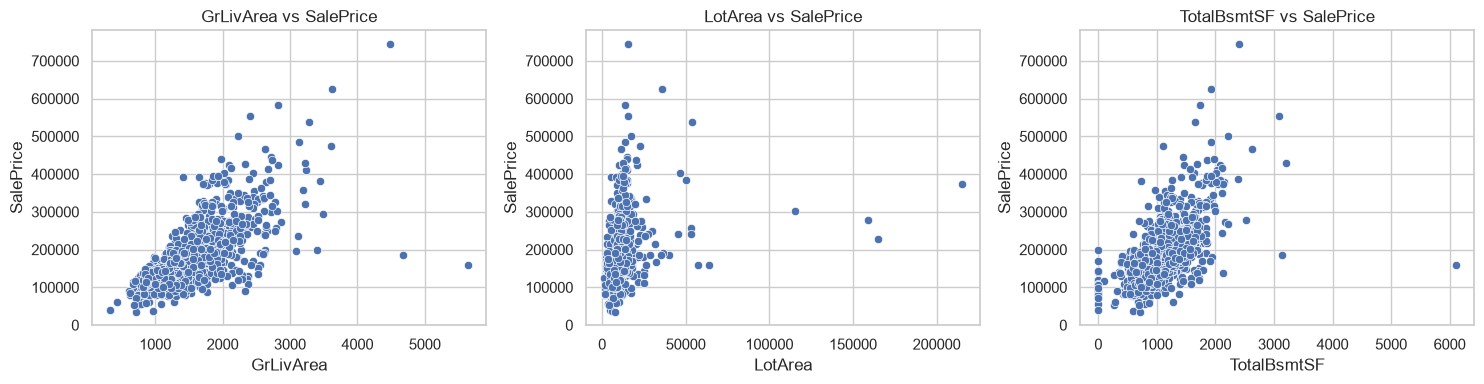

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["GrLivArea", "LotArea", "TotalBsmtSF"]):
    sns.scatterplot(x=df[col], y=df["SalePrice"], ax=ax)
    ax.set_title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()

`GrLivArea` muestra un par de casas muy grandes (>4000 sq ft) vendidas a
precio bajo — outliers conocidos en este dataset (posibles ventas atípicas,
no representativas del patrón general). Se documentará en
`02_experiments.ipynb` si remover estos puntos mejora el RMSE de validación
(una de las iteraciones a probar), en vez de eliminarlos de entrada sin
evidencia.

In [9]:
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000)]
outliers[["Id", "GrLivArea", "SalePrice"]]

,Id,GrLivArea,SalePrice
365,524,4676,184750
495,1299,5642,160000


## 6. Correlaciones

In [10]:
corr = df[numeric_cols].corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.drop("SalePrice").head(15)

OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.480351
MasVnrArea      0.459123
Fireplaces      0.457549
BsmtFinSF1      0.359460
LotFrontage     0.330066
Name: SalePrice, dtype: float64

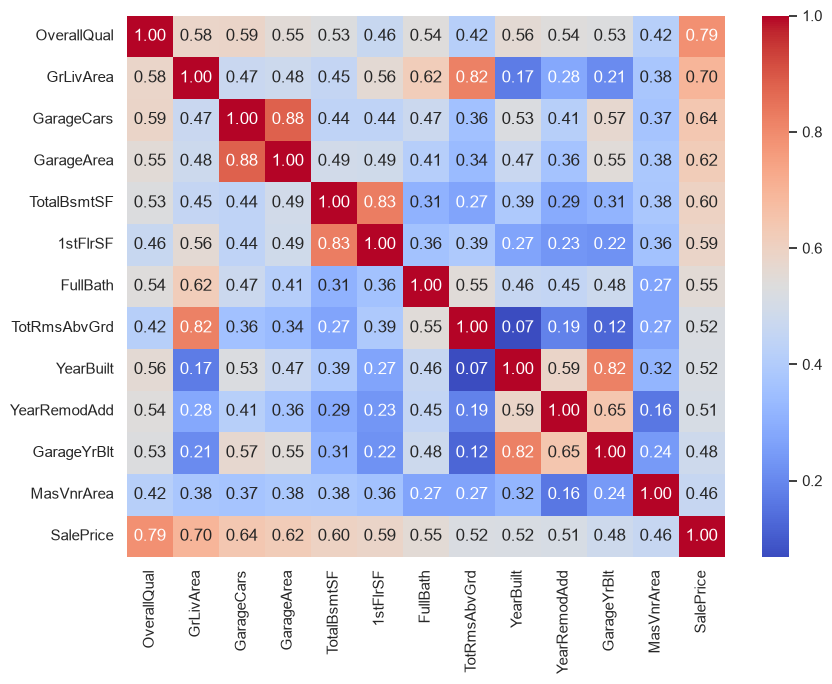

In [11]:
top_feats = corr.drop("SalePrice").abs().sort_values(ascending=False).head(12).index.tolist()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[top_feats + ["SalePrice"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.tight_layout()
plt.show()

`OverallQual`, `GrLivArea`, `GarageCars`/`GarageArea`, `TotalBsmtSF`,
`1stFlrSF` y `YearBuilt` son las más correlacionadas linealmente con
`SalePrice`. `GarageCars` y `GarageArea` están muy correlacionadas entre sí
(redundancia) — se evalúa en experimentos si remover una de las dos ayuda a
un MLP (a diferencia de un modelo lineal, la colinealidad afecta menos a una
red, pero se documenta la observación).

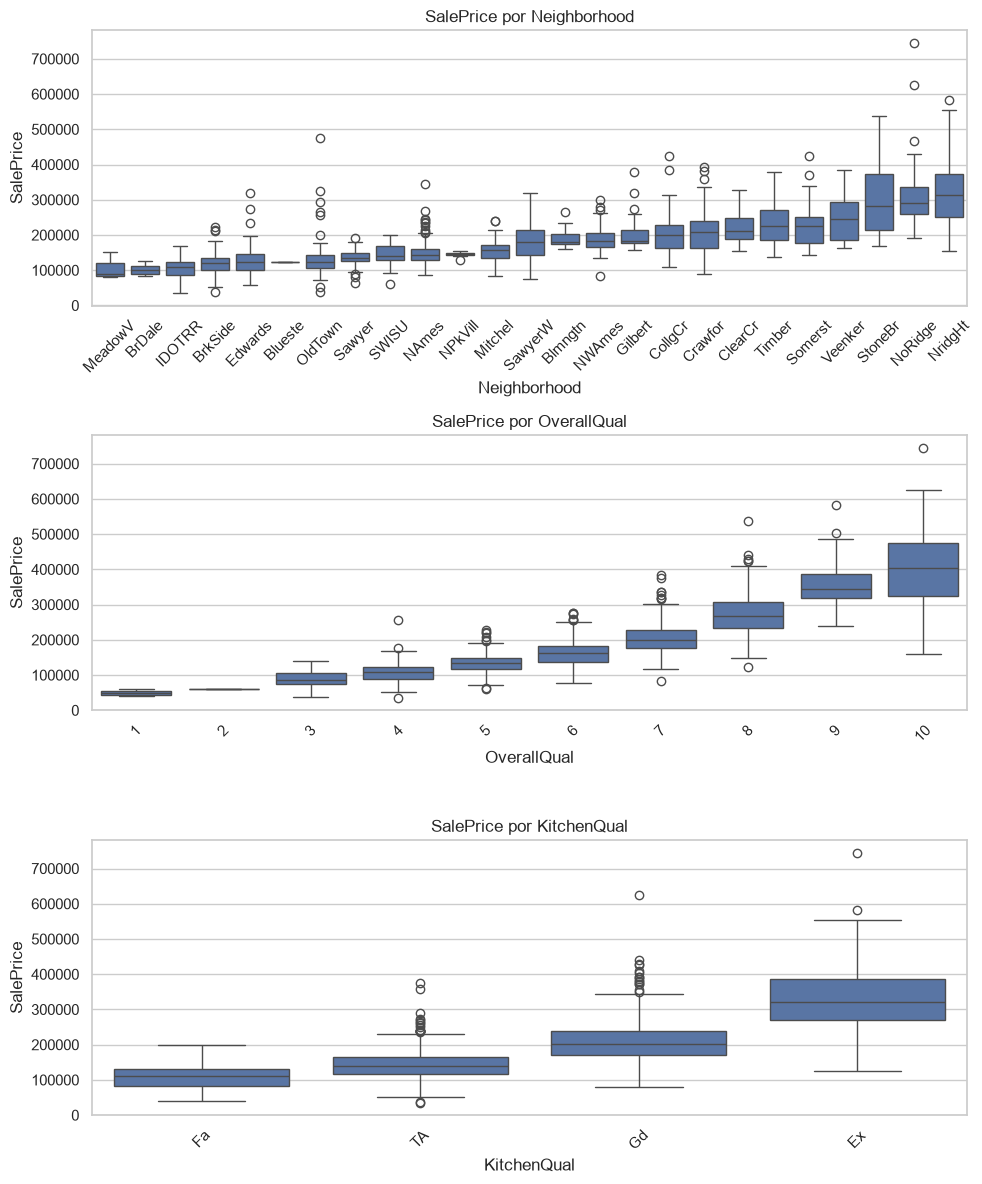

In [12]:
cat_example_cols = ["Neighborhood", "OverallQual", "KitchenQual"]
fig, axes = plt.subplots(len(cat_example_cols), 1, figsize=(10, 4 * len(cat_example_cols)))
for ax, col in zip(axes, cat_example_cols):
    order = df.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(x=col, y="SalePrice", data=df, order=order, ax=ax)
    ax.set_title(f"SalePrice por {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Decisiones de preprocesamiento (resumen)

1. Rellenar NA "estructurales" (ausencia de feature) con `"None"`/`0` en vez
   de moda/media -> `fill_structural_na` en `src/preprocessing.py`.
2. Imputar `LotFrontage` (mediana) y `Electrical` (moda) -> missing real.
3. Mapear columnas de calidad ordinal (`ExterQual`, `KitchenQual`,
   `BsmtExposure`, etc.) a escala numérica en vez de one-hot ->
   `apply_ordinal_maps`.
4. One-hot encoding para el resto de categóricas nominales
   (`handle_unknown="ignore"` para tolerar categorías nuevas en el dataset
   held-out).
5. `StandardScaler` sobre numéricas y ordinales tras imputar.
6. Probar como iteraciones (no decisión de entrada, se valida
   experimentalmente en `02_experiments.ipynb`): `log1p(SalePrice)` como
   target, y remover los 2 outliers de `GrLivArea`.

Todo esto queda implementado de forma reproducible en
`src/preprocessing.py` (`prepare_raw` + `build_preprocessor`), fit únicamente
sobre el set de entrenamiento.